In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
losses_csv = "/mnt/big/jirko/simplicity_transformers/outputs/20260115-164053_pQ=0p050_k=16_s=43/losses/losses.csv"    # change path if needed
df = pd.read_csv(losses_csv)

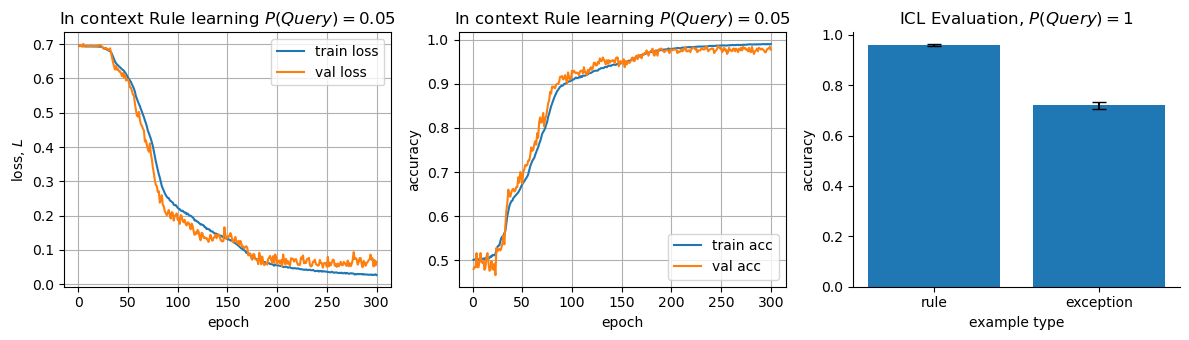

In [44]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3.5))

ax1.plot(df['epoch'], df['train_loss'], label='train loss')
ax1.plot(df['epoch'], df['eval_loss'], label='val loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss, $L$')
ax1.legend()
ax1.grid(True)
ax1.set_title('In context Rule learning $P(Query)=0.05$')

ax2.plot(df['epoch'], df['train_acc'], label='train acc')
ax2.plot(df['epoch'], df['eval_acc'], label='val acc')
ax2.set_xlabel('epoch')
ax2.set_ylabel('accuracy')
ax2.legend()
ax2.grid(True)
ax2.set_title('In context Rule learning $P(Query)=0.05$')

# load summary
df_eval = pd.read_csv("outputs/eval_results/per_example_k=16.csv")
df_eval.head()
# plot a barplot showing correct as a function of boolean is_exception column
# calculate mean and se before plotting
summary = df_eval.groupby('is_exception')['correct'].agg(['mean', 'sem']).reset_index()
# plot the summary as a barplot
ax3.bar(summary['is_exception'], summary['mean'], yerr=summary['sem'], capsize=5)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['rule', 'exception'])
ax3.set_xlabel('example type')
ax3.set_ylabel('accuracy')
ax3.set_title('ICL Evaluation, $P(Query)=1$')
# remove the top and right spines
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

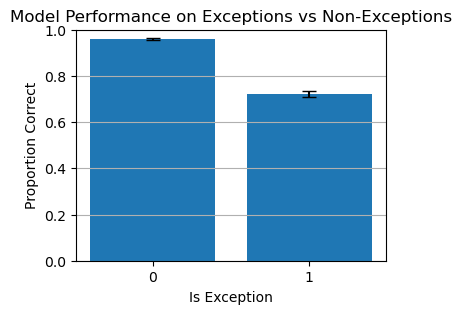

In [ ]:
# load summary
df = pd.read_csv("outputs/eval_results/per_example_k=16.csv")
df.head()
# plot a barplot showing correct as a function of boolean is_exception column
# calculate mean and se before plotting
summary = df.groupby('is_exception')['correct'].agg(['mean', 'sem']).reset_index()
# plot the summary as a barplot
plt.figure(figsize=(4, 3))
plt.bar(summary['is_exception'].astype(str), summary['mean'], yerr=summary['sem'], capsize=5)
plt.xlabel('Is Exception')
plt.ylabel('Proportion Correct')
plt.title('Model Performance on Exceptions vs Non-Exceptions')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()
